In [15]:
# If any of these are missing, uncomment and run:
# !pip install scikit-learn scipy matplotlib numpy pillow pandas --quiet


In [89]:
import os, tarfile, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.cluster import KMeans, DBSCAN, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

np.random.seed(42)


In [90]:
import os

IMAGES_DIR = r"C:\Users\BIT\Downloads\archive (3)\images\train"

image_files = sorted(os.listdir(IMAGES_DIR))

print(f"Found {len(image_files)} training images.")
print(f"Path: {IMAGES_DIR}")
print(f"Example: {image_files[:5]}")

Found 201 training images.
Path: C:\Users\BIT\Downloads\archive (3)\images\train
Example: ['100075.jpg', '100080.jpg', '100098.jpg', '103041.jpg', '104022.jpg']


Feature matrix shape: (1024, 5)


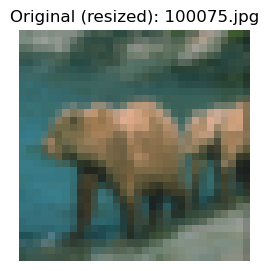

In [91]:
IMAGE_NAME   = image_files[0]     # change this to try a different image
RESIZE_TO    = (32, 32)           # (width, height) - keep small, DIANA/K-Medoids are O(n^2)-O(n^3)
SPATIAL_WEIGHT = 0.4              # weight on (x, y) relative to normalized color
K            = 6                  # target number of clusters/segments

img_path = os.path.join(IMAGES_DIR, IMAGE_NAME)
img = Image.open(img_path).convert("RGB").resize(RESIZE_TO, Image.BILINEAR)
img_arr = np.array(img)
h, w, _ = img_arr.shape

def image_to_features(img_arr, spatial_weight=0.4):
    h, w, _ = img_arr.shape
    color = img_arr.reshape(-1, 3).astype(float) / 255.0
    yy, xx = np.mgrid[0:h, 0:w]
    coords = np.stack([yy.ravel() / h, xx.ravel() / w], axis=1) * spatial_weight
    return np.hstack([color, coords])

X = image_to_features(img_arr, SPATIAL_WEIGHT)
print("Feature matrix shape:", X.shape)

plt.figure(figsize=(3, 3))
plt.imshow(img_arr)
plt.title(f"Original (resized): {IMAGE_NAME}")
plt.axis("off")
plt.show()


## 4. Precompute distance matrix (needed for K-Medoids and DIANA)

In [79]:
dist_matrix = pairwise_distances(X, metric="euclidean")
print("Distance matrix shape:", dist_matrix.shape)


Distance matrix shape: (1024, 1024)


In [80]:
def kmedoids_fit(dist_matrix, k, max_iter=100, random_state=42):
    n = dist_matrix.shape[0]
    rng = np.random.RandomState(random_state)
    medoid_idx = rng.choice(n, k, replace=False)
    for _ in range(max_iter):
        labels = np.argmin(dist_matrix[:, medoid_idx], axis=1)
        new_medoids = medoid_idx.copy()
        for ci in range(k):
            members = np.where(labels == ci)[0]
            if len(members) == 0:
                continue
            sub = dist_matrix[np.ix_(members, members)]
            new_medoids[ci] = members[np.argmin(sub.sum(axis=1))]
        if np.array_equal(new_medoids, medoid_idx):
            break
        medoid_idx = new_medoids
    labels = np.argmin(dist_matrix[:, medoid_idx], axis=1)
    return labels


### 5.2 DIANA (Divisive Analysis)
Classic top-down hierarchical clustering: start with all points in one cluster; repeatedly split the cluster with the largest diameter by pulling out a "splinter group" of points that are, on average, closer to each other than to the rest of the cluster; repeat until `k` clusters exist.


In [81]:
def diana_fit(dist_matrix, k):
    """Fully vectorized DIANA. Still O(n^2)-O(n^3) overall, so keep n (pixel count) small."""
    n = dist_matrix.shape[0]
    clusters = [np.arange(n)]

    def diameter(idxs):
        return 0.0 if len(idxs) < 2 else dist_matrix[np.ix_(idxs, idxs)].max()

    while len(clusters) < k:
        diam = [diameter(c) for c in clusters]
        split_i = int(np.argmax(diam))
        cluster = clusters.pop(split_i)
        if len(cluster) < 2:
            clusters.append(cluster)
            break

        sub = dist_matrix[np.ix_(cluster, cluster)]
        splinter = [cluster[int(np.argmax(sub.mean(axis=1)))]]
        remaining = list(cluster[cluster != splinter[0]])

        moved = True
        while moved and len(remaining) > 1:
            moved = False
            R, S = np.array(remaining), np.array(splinter)
            m = len(R)
            avg_to_remaining = dist_matrix[np.ix_(R, R)].sum(axis=1) / max(m - 1, 1)
            avg_to_splinter = dist_matrix[np.ix_(R, S)].mean(axis=1)
            diff = avg_to_remaining - avg_to_splinter
            idx_max = int(np.argmax(diff))
            if diff[idx_max] > 0:
                remaining.remove(R[idx_max])
                splinter.append(R[idx_max])
                moved = True

        clusters.append(np.array(splinter))
        if remaining:
            clusters.append(np.array(remaining))

    labels = np.empty(n, dtype=int)
    for ci, idxs in enumerate(clusters):
        labels[idxs] = ci
    return labels


### 5.3 Agglomerative Hierarchical Clustering — 5 linkages
Bottom-up: every point starts as its own cluster, and the closest pair of clusters is merged repeatedly. The **linkage** rule defines "closest":
- `single`: minimum distance between any pair of points in the two clusters
- `complete`: maximum distance between any pair
- `average`: mean distance between all pairs
- `ward`: minimizes the increase in total within-cluster variance
- `centroid`: distance between cluster centroids


In [82]:
LINKAGES = ["single", "complete", "average", "ward", "centroid"]

def agglomerative_fit(X, k, method):
    Z = linkage(X, method=method, metric="euclidean")
    labels = fcluster(Z, t=k, criterion="maxclust") - 1  # zero-index
    return labels


### 5.4 K-Means, DBSCAN, BIRCH — using scikit-learn directly

In [83]:
def kmeans_fit(X, k):
    return KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)

def dbscan_fit(X, eps=0.08, min_samples=8):
    return DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)

def birch_fit(X, k):
    return Birch(n_clusters=k, threshold=0.3).fit_predict(X)


In [84]:
def evaluate(X, labels, name, elapsed):
    mask = labels != -1  # drop DBSCAN noise, if any
    n_clusters = len(set(labels[mask]))
    n_noise = int((labels == -1).sum())

    if n_clusters < 2 or mask.sum() < n_clusters:
        sil, db, ch = np.nan, np.nan, np.nan
    else:
        sil = silhouette_score(X[mask], labels[mask])
        db  = davies_bouldin_score(X[mask], labels[mask])
        ch  = calinski_harabasz_score(X[mask], labels[mask])

    return {
        "Algorithm": name,
        "Clusters found": n_clusters,
        "Noise points": n_noise,
        "Silhouette (higher better)": sil,
        "Davies-Bouldin (lower better)": db,
        "Calinski-Harabasz (higher better)": ch,
        "Time (s)": round(elapsed, 3),
    }

def labels_to_image(labels, img_arr, h, w):
    """Recolor each cluster with its mean RGB color for a segmentation preview."""
    flat = img_arr.reshape(-1, 3).astype(float)
    out = np.zeros_like(flat)
    for lab in set(labels):
        mask = labels == lab
        color = flat[mask].mean(axis=0) if lab != -1 else np.array([255, 0, 0])  # red = noise
        out[mask] = color
    return out.reshape(h, w, 3).astype(np.uint8)


## 7. Run every algorithm and collect results

In [85]:
results = []
segmented_images = {}

def run(name, fit_fn):
    t0 = time.time()
    labels = fit_fn()
    elapsed = time.time() - t0
    results.append(evaluate(X, labels, name, elapsed))
    segmented_images[name] = labels_to_image(labels, img_arr, h, w)
    print(f"{name:22s} done in {elapsed:.2f}s")

run("K-Means",              lambda: kmeans_fit(X, K))
run("K-Medoids",            lambda: kmedoids_fit(dist_matrix, K))
run("DBSCAN",                lambda: dbscan_fit(X, eps=0.08, min_samples=8))
run("DIANA",                lambda: diana_fit(dist_matrix, K))
for method in LINKAGES:
    run(f"Agglomerative-{method}", lambda m=method: agglomerative_fit(X, K, m))
run("BIRCH",                 lambda: birch_fit(X, K))

results_df = pd.DataFrame(results)
results_df


C:\Users\BIT\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K-Means                done in 0.08s
K-Medoids              done in 0.01s
DBSCAN                 done in 0.02s
DIANA                  done in 2.70s
Agglomerative-single   done in 0.01s
Agglomerative-complete done in 0.02s
Agglomerative-average  done in 0.02s
Agglomerative-ward     done in 0.03s
Agglomerative-centroid done in 0.02s
BIRCH                  done in 0.02s


C:\Users\BIT\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_birch.py:727: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (6). Decrease the threshold.
  warnings.warn(


,Algorithm,Clusters found,Noise points,Silhouette (higher better),Davies-Bouldin (lower better),Calinski-Harabasz (higher better),Time (s)
0,K-Means,6,0,0.405762,0.893812,773.240203,0.080
1,K-Medoids,6,0,0.401769,0.899453,765.715338,0.007
2,DBSCAN,3,1,0.294838,1.015624,440.984084,0.015
3,DIANA,6,0,0.379602,0.952368,710.560917,2.696
4,Agglomerative-single,6,0,0.068755,1.408081,183.900442,0.010
5,Agglomerative-complete,6,0,0.370695,0.931259,699.113927,0.020
6,Agglomerative-average,6,0,0.379796,0.971168,689.773230,0.022
7,Agglomerative-ward,6,0,0.358650,0.970753,644.486829,0.026
8,Agglomerative-centroid,6,0,0.350326,0.928106,642.690711,0.025
9,BIRCH,1,0,NaN,NaN,NaN,0.023


BIRCH                  done in 0.02s


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_birch.py:711: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (6). Decrease the threshold.
  warnings.warn(


,Algorithm,Clusters found,Noise points,Silhouette (higher better),Davies-Bouldin (lower better),Calinski-Harabasz (higher better),Time (s)
0,K-Means,6,0,0.351438,1.068040,532.585188,0.057
1,K-Medoids,6,0,0.259877,1.403309,437.002370,0.010
2,DBSCAN,3,45,0.003556,0.795905,27.701704,0.012
3,DIANA,6,0,0.269157,1.139105,398.518498,2.432
4,Agglomerative-single,6,0,-0.200647,1.072008,9.472776,0.009
5,Agglomerative-complete,6,0,0.203677,1.221741,317.367041,0.016
6,Agglomerative-average,6,0,0.310723,1.125080,365.727620,0.015
7,Agglomerative-ward,6,0,0.300321,1.160121,423.844146,0.018
8,Agglomerative-centroid,6,0,0.261451,1.054292,310.650027,0.019
9,BIRCH,1,0,NaN,NaN,NaN,0.015


## 8. Visualize the segmentations side by side

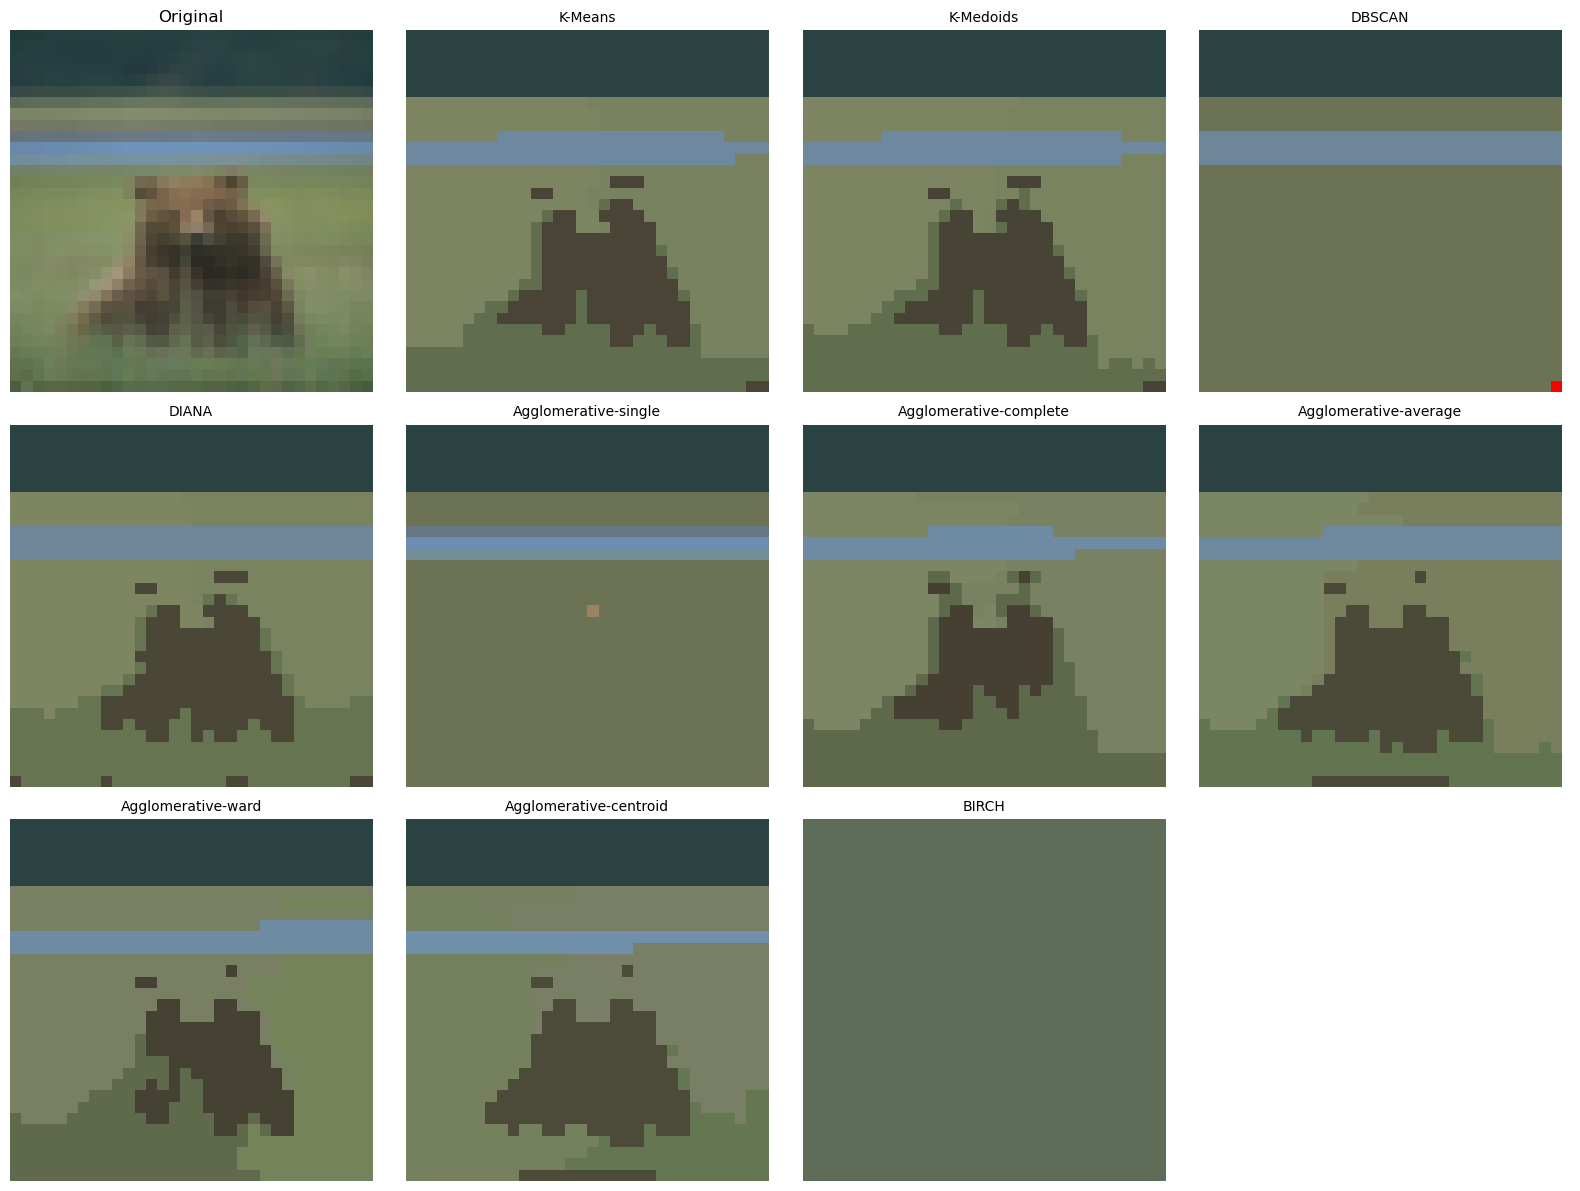

In [86]:
n_algos = len(segmented_images)
cols = 4
rows = int(np.ceil((n_algos + 1) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

axes[0].imshow(img_arr); axes[0].set_title("Original"); axes[0].axis("off")

for i, (name, seg) in enumerate(segmented_images.items(), start=1):
    axes[i].imshow(seg)
    axes[i].set_title(name, fontsize=10)
    axes[i].axis("off")

for j in range(n_algos + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


## 9. Compare internal metrics across algorithms

In [87]:
display_df = results_df.sort_values("Silhouette (higher better)", ascending=False).reset_index(drop=True)
display_df


,Algorithm,Clusters found,Noise points,Silhouette (higher better),Davies-Bouldin (lower better),Calinski-Harabasz (higher better),Time (s)
0,K-Means,6,0,0.405762,0.893812,773.240203,0.080
1,K-Medoids,6,0,0.401769,0.899453,765.715338,0.007
2,Agglomerative-average,6,0,0.379796,0.971168,689.773230,0.022
3,DIANA,6,0,0.379602,0.952368,710.560917,2.696
4,Agglomerative-complete,6,0,0.370695,0.931259,699.113927,0.020
5,Agglomerative-ward,6,0,0.358650,0.970753,644.486829,0.026
6,Agglomerative-centroid,6,0,0.350326,0.928106,642.690711,0.025
7,DBSCAN,3,1,0.294838,1.015624,440.984084,0.015
8,Agglomerative-single,6,0,0.068755,1.408081,183.900442,0.010
9,BIRCH,1,0,NaN,NaN,NaN,0.023


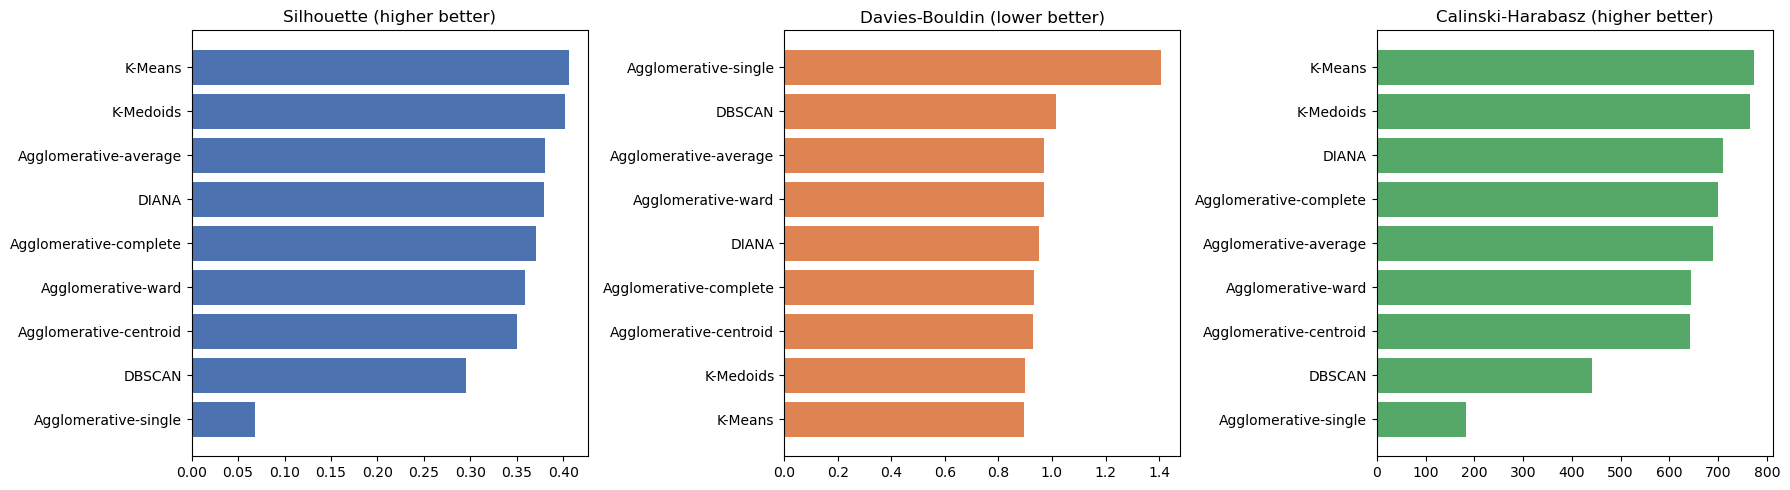

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["Silhouette (higher better)", "Davies-Bouldin (lower better)", "Calinski-Harabasz (higher better)"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, c in zip(axes, metrics, colors):
    d = results_df.dropna(subset=[metric]).sort_values(metric, ascending=False)
    ax.barh(d["Algorithm"], d[metric], color=c)
    ax.set_title(metric)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()
